# 1. Imports

In [2]:
import os
import re
from collections import Counter
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

from IPython.display import display

print("TensorFlow:", tf.__version__)
nltk.download("stopwords")

TensorFlow: 2.18.1


[nltk_data] Downloading package stopwords to /home/rabby/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 2. Fixed Hyperparameters

In [5]:
# Model Hyperparameters
EMBEDDING_DIM = 300       # GloVe vector size
BATCH_SIZE = 10000        # Required batch size
EPOCHS = 10               # Required training epochs
LR = 1e-3                 # Learning rate
MODEL_PATH_LSTM_BEST = "saved_models/lstm_best.h5"
MODEL_PATH_LSTM_FINAL = "saved_models/lstm_final_model.h5"

# Tokenizer / Sequence Hyperparameters
MAX_WORDS = 100000        # Vocabulary size
MAX_SEQ_LENGTH = 30       # Max tweet length (in tokens)

# Paths
DATA_PATH = "data/training.1600000.processed.noemoticon.csv"
GLOVE_PATH = "data/glove.6B.300d.txt"

os.makedirs("saved_models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# 3. Load Dataset

In [8]:
df = pd.read_csv(
    DATA_PATH,
    header=None,
    engine="python",
    encoding="latin-1",
    encoding_errors="ignore"
)

df.columns = ["sentiment", "id", "date", "query", "user_id", "text"]
df = df[["sentiment", "text"]]

print(df.shape)
display(df.head())

(1600000, 2)


,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


# 4. EDA (Exploratory Data Analysis)

## Sentiment Distribution

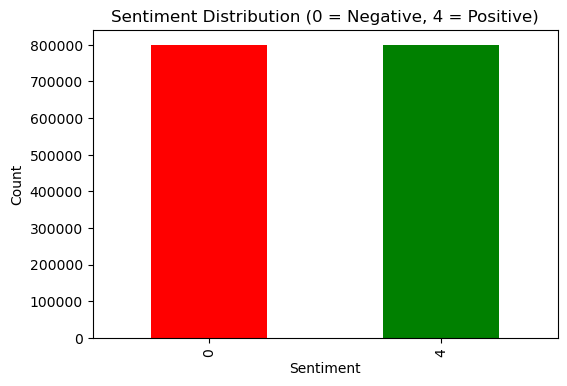

In [12]:
# Sentiment Distribution
plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar', color=['red','green'])
plt.title("Sentiment Distribution (0 = Negative, 4 = Positive)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## Tweet Length (Histogram + Boxplot)

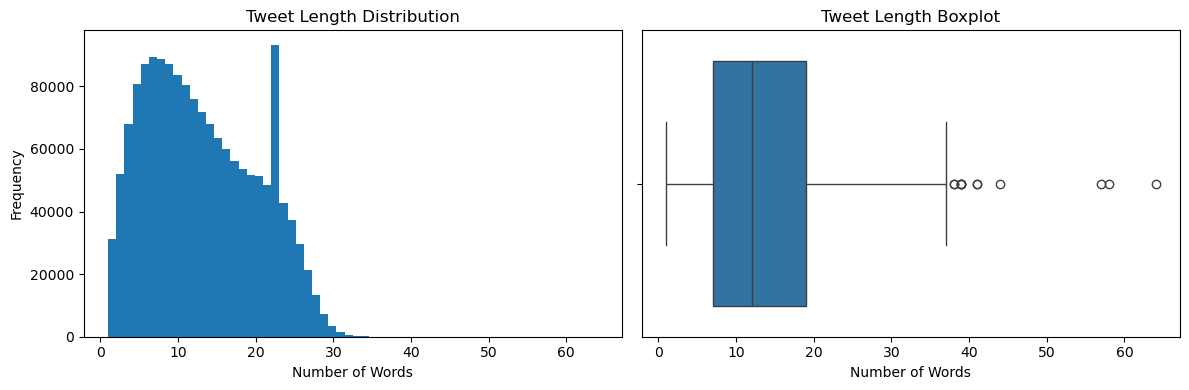

In [15]:
df["text_len"] = df["text"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of lengths
axes[0].hist(df["text_len"], bins=60)
axes[0].set_title("Tweet Length Distribution")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")

# Boxplot to show spread and outliers
sns.boxplot(x=df["text_len"], ax=axes[1])
axes[1].set_title("Tweet Length Boxplot")
axes[1].set_xlabel("Number of Words")

plt.tight_layout()
plt.show()

## WordClouds (Negative vs Positive)

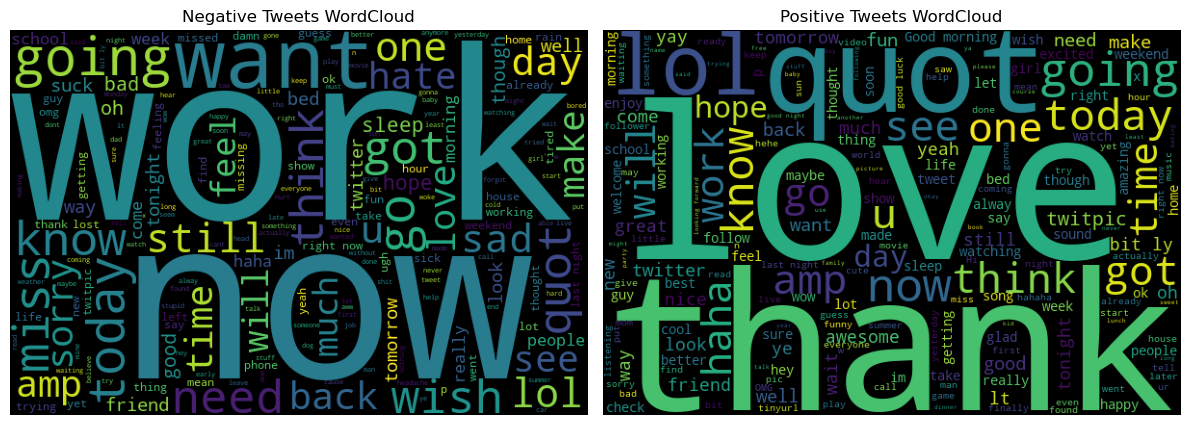

In [18]:
neg_text = " ".join(df[df["sentiment"] == 0]["text"].astype(str).tolist())
pos_text = " ".join(df[df["sentiment"] == 4]["text"].astype(str).tolist())

plt.figure(figsize=(12, 5))

# Negative
plt.subplot(1, 2, 1)
wc_neg = WordCloud(width=600, height=400, background_color="black").generate(neg_text)
plt.imshow(wc_neg)
plt.title("Negative Tweets WordCloud")
plt.axis("off")

# Positive
plt.subplot(1, 2, 2)
wc_pos = WordCloud(width=600, height=400, background_color="black").generate(pos_text)
plt.imshow(wc_pos)
plt.title("Positive Tweets WordCloud")
plt.axis("off")

plt.tight_layout()
plt.show()

## Top 20 Words (Negative vs Positive)

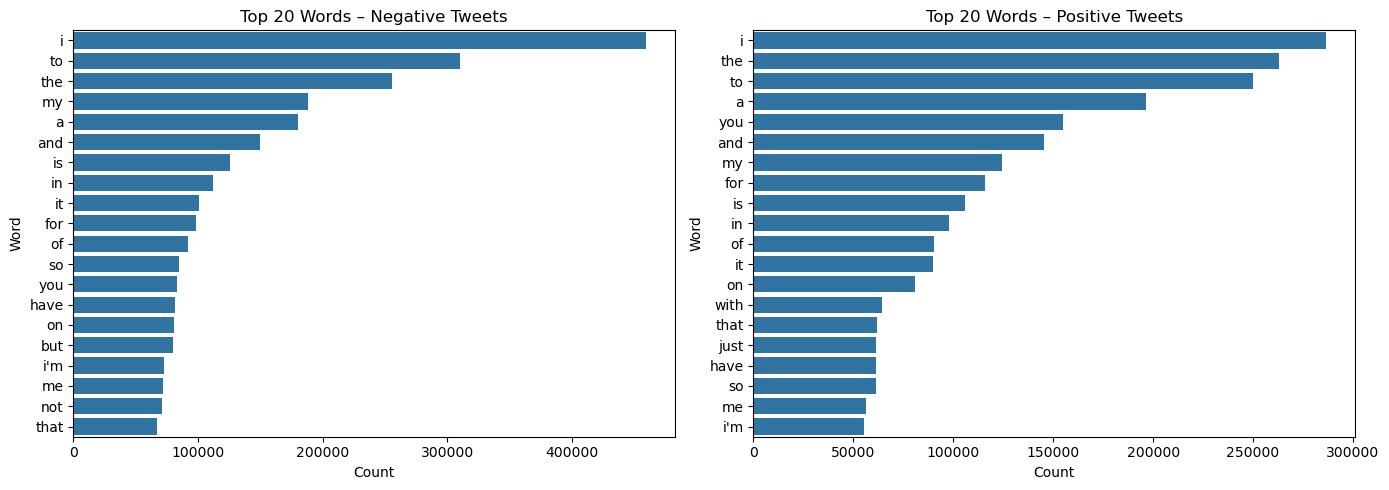

In [21]:
def top_n_words(texts, n=20):
    all_words = " ".join(texts).lower().split()
    counter = Counter(all_words)
    return counter.most_common(n)

top_neg = top_n_words(df[df["sentiment"] == 0]["text"].astype(str), n=20)
top_pos = top_n_words(df[df["sentiment"] == 4]["text"].astype(str), n=20)

# Convert to DataFrame for plotting
neg_words, neg_counts = zip(*top_neg)
pos_words, pos_counts = zip(*top_pos)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=list(neg_counts), y=list(neg_words), ax=axes[0])
axes[0].set_title("Top 20 Words – Negative Tweets")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Word")

sns.barplot(x=list(pos_counts), y=list(pos_words), ax=axes[1])
axes[1].set_title("Top 20 Words – Positive Tweets")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Word")

plt.tight_layout()
plt.show()

# 5. Text Preprocessing

In [24]:
stop_words = stopwords.words("english")
stemmer = SnowballStemmer("english")

clean_re = r'@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+'  # remove mentions, URLs, non-alphanum

def preprocess(text, stem=False):
    text = re.sub(clean_re, " ", str(text).lower()).strip()
    tokens = []
    for token in text.split():
        if token not in stop_words:
            tokens.append(stemmer.stem(token) if stem else token)
    return " ".join(tokens)

# 6. Apply Cleaning

In [27]:
df["clean_text"] = df["text"].apply(preprocess)

display(df[["text", "clean_text"]].head())

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset update facebook texting might cry result...
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save 50 rest go ...
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving mad see


# 7. Train/Test Split

In [30]:
train_df, test_df = train_test_split(
    df[["sentiment", "clean_text"]],
    test_size=0.2,
    random_state=666,
    shuffle=True
)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (1280000, 2)
Test size: (320000, 2)


# 8. Tokenizer & Padding

In [33]:
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(train_df["clean_text"])

x_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

x_test = pad_sequences(
    tokenizer.texts_to_sequences(test_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

# 0 → negative, 4 → positive → convert to 0/1
y_train = (train_df["sentiment"] == 4).astype(int).values
y_test = (test_df["sentiment"] == 4).astype(int).values

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1280000, 30)
x_test shape: (320000, 30)
y_train shape: (1280000,)
y_test shape: (320000,)


# 9. Load GloVe Embeddings

In [36]:
embedding_index = {}

with open(GLOVE_PATH, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("Loaded word vectors:", len(embedding_index))

Loaded word vectors: 400000


# 10. Build Embedding Matrix

In [39]:
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

for word, idx in tokenizer.word_index.items():
    if idx < vocab_size:
        vec = embedding_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (290683, 300)


# 11. Build LSTM Model

In [42]:
lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_shape=(MAX_SEQ_LENGTH,),
        trainable=False
    ),
    LSTM(128),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    metrics=["accuracy"]
)

lstm_model.summary()

/home/rabby/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 300)        │    87,204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,424,677 (333.50 MB)

 Trainable params: 219,777 (858.50 KB)

 Non-trainable params: 87,204,900 (332.66 MB)

# 12. Train LSTM Model (Record Training Time)

In [45]:
start_time = time.time()

history_lstm = lstm_model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
)

end_time = time.time()
training_time_lstm = end_time - start_time

print(f"LSTM Training time: {training_time_lstm:.2f} seconds")

Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.7141 - loss: 0.5534 - val_accuracy: 0.7422 - val_loss: 0.5156
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.7514 - loss: 0.5025 - val_accuracy: 0.7617 - val_loss: 0.4885
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.7643 - loss: 0.4842 - val_accuracy: 0.7688 - val_loss: 0.4779
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.7713 - loss: 0.4741 - val_accuracy: 0.7724 - val_loss: 0.4716
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.7760 - loss: 0.4667 - val_accuracy: 0.7738 - val_loss: 0.4704
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.7796 - loss: 0.4613 - val_accuracy: 0.7755 - val_loss: 0.4671
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.7826 - loss: 0.4565 - val_accuracy: 0.7807 - val_loss: 0.4597
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.7851 - loss: 0.4526 - val_accu

# 13. Visualization

## 13.1 LSTM Loss Curves

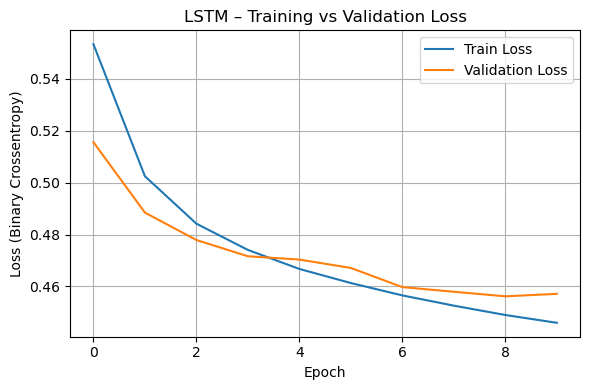

In [49]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(6, 4))
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Crossentropy)")
plt.title("LSTM – Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 13.2 LSTM Accuracy Curves

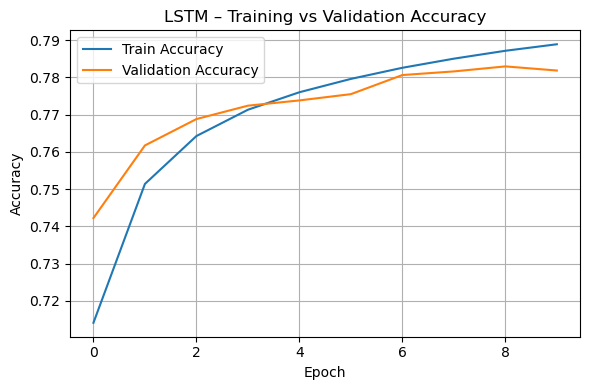

In [52]:
plt.figure(figsize=(6, 4))
plt.plot(history_lstm.history["accuracy"], label="Train Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM – Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 13.3 LSTM Test Evaluation

In [55]:
test_loss_lstm, test_acc_lstm = lstm_model.evaluate(
    x_test, y_test,
    batch_size=BATCH_SIZE
)

print(f"LSTM – Test Loss:     {test_loss_lstm:.4f}")
print(f"LSTM – Test Accuracy: {test_acc_lstm:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 907ms/step - accuracy: 0.7819 - loss: 0.4573
LSTM – Test Loss:     0.4573
LSTM – Test Accuracy: 0.7819


## 13.4 LSTM Confusion Matrix, F1, Classification Report

32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step


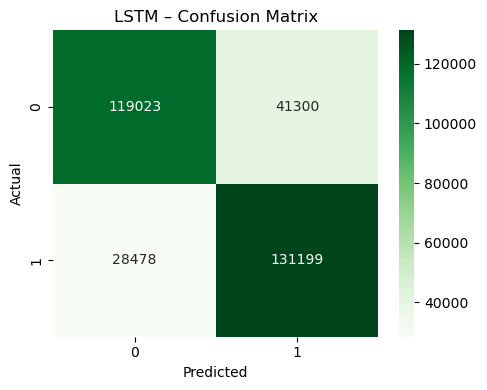


LSTM – Classification Report:

              precision    recall  f1-score   support

    Negative       0.81      0.74      0.77    160323
    Positive       0.76      0.82      0.79    159677

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000

LSTM – F1-score: 0.7899


In [60]:
y_prob_lstm = lstm_model.predict(x_test, batch_size=BATCH_SIZE)
y_pred_lstm = (y_prob_lstm >= 0.5).astype("int32").ravel()

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Greens")
plt.title("LSTM – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

f1_lstm = f1_score(y_test, y_pred_lstm)
print("\nLSTM – Classification Report:\n")
print(classification_report(y_test, y_pred_lstm, target_names=["Negative","Positive"]))
print(f"LSTM – F1-score: {f1_lstm:.4f}")

## 13.5 LSTM Prediction Probability Distribution

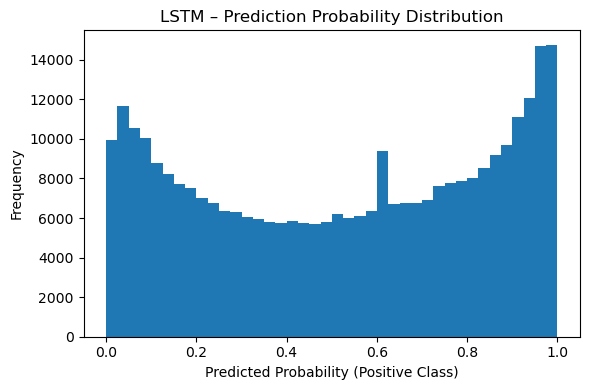

In [65]:
plt.figure(figsize=(6, 4))
plt.hist(y_prob_lstm, bins=40)
plt.xlabel("Predicted Probability (Positive Class)")
plt.ylabel("Frequency")
plt.title("LSTM – Prediction Probability Distribution")
plt.tight_layout()
plt.show()

# 14. Save LSTM Model & Tokenizer

In [68]:
lstm_model.save(MODEL_PATH_LSTM_FINAL)

import pickle
with open("saved_models/tokenizer_lstm.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print(f"Saved best LSTM model to: {MODEL_PATH_LSTM_BEST}")
print(f"Saved final LSTM model to: {MODEL_PATH_LSTM_FINAL}")
print("Saved tokenizer to: saved_models/tokenizer_lstm.pkl")

Saved best LSTM model to: saved_models/lstm_best.h5
Saved final LSTM model to: saved_models/lstm_final_model.h5
Saved tokenizer to: saved_models/tokenizer_lstm.pkl


# 15. Load Saved RNN Model from Level 1 (for Comparison)

In [71]:
RNN_MODEL_PATH = "saved_models/rnn_final_model.h5"
RNN_TOKENIZER_PATH = "saved_models/tokenizer.pkl"

rnn_model = tf.keras.models.load_model(RNN_MODEL_PATH)

with open(RNN_TOKENIZER_PATH, "rb") as f:
    rnn_tokenizer = pickle.load(f)

print("Loaded RNN model and tokenizer from Level 1.")

Loaded RNN model and tokenizer from Level 1.


# 16. Evaluate RNN on the Same Test Set (Using Level 2 Test Data)

In [74]:
# We must encode test_df["clean_text"] using the RNN tokenizer
x_test_rnn = pad_sequences(
    rnn_tokenizer.texts_to_sequences(test_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

test_loss_rnn, test_acc_rnn = rnn_model.evaluate(
    x_test_rnn, y_test,
    batch_size=BATCH_SIZE
)

y_prob_rnn = rnn_model.predict(x_test_rnn, batch_size=BATCH_SIZE)
y_pred_rnn = (y_prob_rnn >= 0.5).astype("int32").ravel()
f1_rnn = f1_score(y_test, y_pred_rnn)

print(f"RNN – Test Loss:     {test_loss_rnn:.4f}")
print(f"RNN – Test Accuracy: {test_acc_rnn:.4f}")
print(f"RNN – F1-score:      {f1_rnn:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 357ms/step - accuracy: 0.7573 - loss: 0.4959
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 373ms/step
RNN – Test Loss:     0.4959
RNN – Test Accuracy: 0.7573
RNN – F1-score:      0.7620


# 17. RNN vs LSTM Comparison Table + F1 Bar Plot

,Model,Accuracy,F1-score
0,RNN,0.757306,0.762042
1,LSTM,0.781944,0.789937


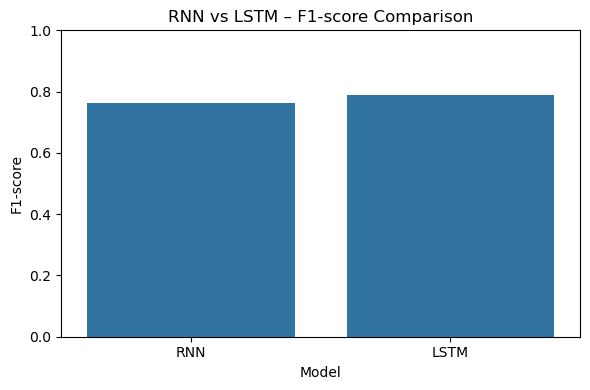

In [77]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "Accuracy": [test_acc_rnn, test_acc_lstm],
    "F1-score": [f1_rnn, f1_lstm]
})

display(results)

plt.figure(figsize=(6, 4))
sns.barplot(x="Model", y="F1-score", data=results)
plt.title("RNN vs LSTM – F1-score Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Model Complexity & Training Time Comparison

,Model,Parameters,Training_Time_sec
0,RNN,87259941,NaN
1,LSTM,87424677,1893.593256


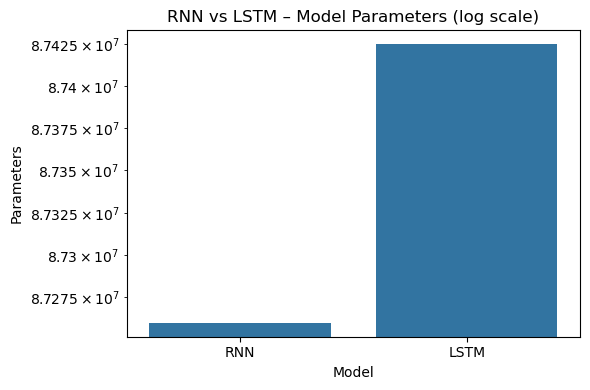

In [80]:
params_rnn = rnn_model.count_params()
params_lstm = lstm_model.count_params()

comp_df = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "Parameters": [params_rnn, params_lstm],
    "Training_Time_sec": [np.nan, training_time_lstm]  # we only timed LSTM here
})

display(comp_df)

plt.figure(figsize=(6, 4))
sns.barplot(x="Model", y="Parameters", data=comp_df)
plt.yscale("log")
plt.title("RNN vs LSTM – Model Parameters (log scale)")
plt.tight_layout()
plt.show()

## Real-Time Prediction Using LSTM

In [83]:
# Load best LSTM model for prediction (ensure using best weights)
lstm_loaded = tf.keras.models.load_model(MODEL_PATH_LSTM_BEST)

with open("saved_models/tokenizer_lstm.pkl", "rb") as f:
    tokenizer_loaded_lstm = pickle.load(f)

def predict_sentiment_lstm(text: str):
    cleaned = preprocess(text)
    seq = tokenizer_loaded_lstm.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_SEQ_LENGTH)
    prob = lstm_loaded.predict(pad)[0][0]
    label = "Positive" if prob >= 0.5 else "Negative"
    return label, float(prob)

# Demo
print(predict_sentiment_lstm("I really love this course, it is amazing!"))
print(predict_sentiment_lstm("This is the worst movie I have ever watched."))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
('Positive', 0.9875080585479736)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
('Negative', 0.06711100041866302)
